<a href="https://colab.research.google.com/github/paracelsus12-crypto/digital-twin-icu/blob/main/%D0%92%D0%B0%D0%BB%D1%96%D0%B4%D0%B0%D1%86%D1%96%D1%8F_%D0%A4%D0%9F_1_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/paracelsus12-crypto/digital-twin-icu.git

Cloning into 'digital-twin-icu'...
remote: Enumerating objects: 145, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (130/130), done.
remote: Total 145 (delta 22), reused 134 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (145/145), 23.59 MiB | 10.74 MiB/s, done.
Resolving deltas: 100% (22/22), done.


In [ ]:
!pip install scikit-learn pandas numpy joblib matplotlib -q

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Контрольна група аспірантура.csv to Контрольна група аспірантура (1).csv


In [ ]:
import os
print("Моделі:", os.listdir('/content/digital-twin-icu/models/cardiac/'))
print("CSV:", [f for f in os.listdir('/content/') if '.csv' in f])

Моделі: ['model_cardiac_lco.pkl', 'model_cardiac_infection_v2.pkl', 'model_cardiac_respiratory_v2.pkl', 'model_cardiac_aki.pkl', 'model_cardiac_stroke.pkl', 'model_cardiac_respiratory.pkl', 'model_cardiac_af.pkl', 'model_cardiac_delirium.pkl', 'model_cardiac_aki_v2.pkl', 'model_cardiac_infection.pkl', 'model_cardiac_delirium_v2.pkl', 'model_cardiac_lco_v2.pkl', 'model_cardiac_stroke_v2.pkl', 'model_cardiac_af_v2.pkl']
CSV: ['Контрольна група аспірантура (1).csv', 'Контрольна група аспірантура.csv']


In [ ]:
import warnings, joblib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')

CSV_PATH   = "/content/Контрольна група аспірантура.csv"
MODEL_DIR  = "/content/digital-twin-icu/models/cardiac"

# ── 1. Завантаження CSV ──────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH, sep=';', encoding='utf-8-sig', header=0)
df = df_raw[df_raw['ПІБ'].notna() &
            (df_raw['ПІБ'].str.strip() != '') &
            (~df_raw['ПІБ'].str.startswith('ПІБ'))].copy().reset_index(drop=True)
print(f"Пацієнтів: {len(df)}")

# ── 2. Парсинг ───────────────────────────────────────────────────
def num(v):
    try:
        return float(str(v).strip().replace(',','.').replace(' ','').replace('\xa0',''))
    except:
        return np.nan

def parse_age(v):
    m = re.findall(r'\d+', str(v))
    return int(m[0]) if m

SyntaxError: expected 'else' after 'if' expression (2546508801.py, line 28)

In [ ]:
import warnings, joblib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')

CSV_PATH   = "/content/Контрольна група аспірантура.csv"
MODEL_DIR  = "/content/digital-twin-icu/models/cardiac"

# ── 1. Завантаження CSV ──────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH, sep=';', encoding='utf-8-sig', header=0)
df = df_raw[df_raw['ПІБ'].notna() &
            (df_raw['ПІБ'].str.strip() != '') &
            (~df_raw['ПІБ'].str.startswith('ПІБ'))].copy().reset_index(drop=True)
print(f"Пацієнтів: {len(df)}")

# ── 2. Парсинг ───────────────────────────────────────────────────
def num(v):
    try:
        return float(str(v).strip().replace(',','.').replace(' ','').replace('\xa0',''))
    except:
        return np.nan

def parse_age(v):
    m = re.findall(r'\d+', str(v))
    return int(m[0]) if m else np.nan

def parse_ckd(v):
    s = str(v).lower()
    for n, k in [(5,'g5'),(4,'g4'),(3,'g3'),(2,'g2'),(1,'g1')]:
        if k in s:
            return n
    return 0

df['age']      = df['Вік'].apply(parse_age)
df['hb_pre']   = df['Hb доопераційний, г/л'].apply(num)
df['cr_pre']   = df['Креатинін доопераційний, мкмоль/л'].apply(num)
df['cr_post']  = df['Креатинін післяопераційний'].apply(num)
df['ef']       = df['ФВ доопераційна, %'].apply(num)
df['ckd_pre']  = df['Ступінь ХХН по KDiGo доопераційний'].apply(parse_ckd)
df['ckd_post'] = df['Ступінь ХХН по KDiGo післяопераційний'].apply(parse_ckd)

df['diabetes'] = df['ЦД'].apply(
    lambda x: 0 if str(x).strip() in ['-','0','nan',''] else 1)

df['emergency'] = df['Взято ургентно/планово'].str.lower().str.contains(
    'ургент|екстрен', na=False).astype(int)

df['cpb_raw'] = df['ШК, 1 - був, 0 - не було'].apply(
    lambda x: 1 if str(x).strip() in ['1','Т','Так','так'] else 0)

df['ihd'] = df['Діагноз'].str.lower().str.contains(
    'іхс|ішемічна|атеросклероз|стенокард|інфаркт', na=False).astype(int)

op_col = 'Операція (назва, з ШК чи без)' if 'Операція (назва, з ШК чи без)' in df.columns else 'Операція '
df['surgery_cabg']  = df[op_col].str.lower().str.contains('акш|мкш', na=False).astype(int)
df['surgery_valve'] = df[op_col].str.lower().str.contains(
    'пак|пмк|плмк|плтк|атк|мнд|анд', na=False).astype(int)

# ── 3. Кінцеві точки ────────────────────────────────────────────
def postop_af(row):
    pre = str(row.get('Дані ЕКГ при поступленні', '')).lower()
    if any(k in pre for k in ['фп постійна', 'фібриляція передсердь']):
        return 0
    for col in ['Дані ЕКГ після операції', 'ШВРС', 'Порушення ритму в анамнезі']:
        v = str(row.get(col, '')).lower()
        if 'фп' in v or 'фібриляція' in v:
            return 1
    return 0

def aki(row):
    cp, cpo = row['cr_pre'], row['cr_post']
    if pd.notna(cp) and pd.notna(cpo) and cp > 0:
        if cpo / cp >= 1.5 or cpo - cp >= 26.5:
            return 1
    if row['ckd_pre'] < row['ckd_post'] >= 3:
        return 1
    return 0

df['y_af']  = df.apply(postop_af, axis=1)
df['y_aki'] = df.apply(aki, axis=1)
df['y_ino'] = df['Підтримка симпатоміметиками після операції/терапії'].apply(
    lambda x: 1 if pd.notna(x) and str(x).strip() not in ['-','0','ні','nan','Ні',''] else 0)

print(f"ФП:    {df['y_af'].sum()}  ({df['y_af'].mean()*100:.1f}%)")
print(f"ГНН:   {df['y_aki'].sum()} ({df['y_aki'].mean()*100:.1f}%)")
print(f"Інотр: {df['y_ino'].sum()} ({df['y_ino'].mean()*100:.1f}%)")

# ── 4. Матриця ознак ─────────────────────────────────────────────
X = pd.DataFrame({
    'age':               df['age'],
    'sex':               1,
    'weight':            80,
    'height':            172,
    'bmi':               27.0,
    'creatinine':        df['cr_pre'] / 88.4,
    'hemoglobin':        df['hb_pre'] / 10,
    'glucose':           5.5,
    'diabetes':          df['diabetes'],
    'hypertension':      df['ihd'],
    'ckd_stage':         df['ckd_pre'],
    'copd':              0,
    'smoking':           0,
    'asa_class':         3,
    'ejection_fraction': df['ef'],
    'ihd':               df['ihd'],
    'cpb_duration':      df['cpb_raw'] * 90,
    'surgery_cabg':      df['surgery_cabg'],
    'surgery_valve':     df['surgery_valve'],
    'surgery_duration':  240,
})
X = X.fillna(X.median())
print(f"\nМатриця ознак: {X.shape}")

# ── 5. Прогнозування ─────────────────────────────────────────────
MODELS = {
    'af':          (f'{MODEL_DIR}/model_cardiac_af_v2.pkl',          df['y_af'],  'Нова ФП'),
    'aki':         (f'{MODEL_DIR}/model_cardiac_aki_v2.pkl',         df['y_aki'], 'ГНН KDIGO>=1'),
    'lco':         (f'{MODEL_DIR}/model_cardiac_lco_v2.pkl',         df['y_ino'], 'Низький СВ (proxy)'),
    'delirium':    (f'{MODEL_DIR}/model_cardiac_delirium_v2.pkl',    None,        'Делірій'),
    'respiratory': (f'{MODEL_DIR}/model_cardiac_respiratory_v2.pkl', None,        'Дих. ускладнення'),
}

PUB_TRAIN = {'af':0.935,'aki':0.925,'lco':0.920,'delirium':0.910,'respiratory':0.925}
PUB_VAL   = {'af':0.72, 'aki':0.68, 'lco':0.69, 'delirium':0.71, 'respiratory':0.73}

results = {}
for key, (path, y_true, label) in MODELS.items():
    m = joblib.load(path)
    y_prob = m.predict_proba(X)[:, 1]
    row = {'label':label, 'y_prob':y_prob, 'y_true':None, 'auc':np.nan, 'brier':np.nan}
    if y_true is not None and y_true.sum() >= 5:
        row['y_true'] = y_true.values
        row['auc']    = roc_auc_score(y_true, y_prob)
        row['brier']  = brier_score_loss(y_true, y_prob)
    results[key] = row
    auc_str = f"{row['auc']:.3f}" if not np.isnan(row['auc']) else "–"
    pt = PUB_TRAIN.get(key, '–')
    pv = PUB_VAL.get(key, '–')
    print(f"{label:30s}  AUC={auc_str}  (навч={pt}, VitalDB={pv})")

# ── 6. Графіки ───────────────────────────────────────────────────
valid = {k:v for k,v in results.items()
         if v['y_true'] is not None and not np.isnan(v['auc'])}
n = len(valid)

fig, axes = plt.subplots(2, n, figsize=(5*n, 9))
if n == 1:
    axes = axes.reshape(2, 1)
colors = ['#3266ad','#c67f0a','#2d8c4e']

for i, (key, res) in enumerate(valid.items()):
    yt  = res['y_true']
    yp  = res['y_prob']
    col = colors[i % len(colors)]

    ax = axes[0, i]
    fpr, tpr, _ = roc_curve(yt, yp)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"AUC = {res['auc']:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.08, color=col)
    ax.plot([0,1],[0,1],'--', color='#aaa', lw=1)
    pub = PUB_VAL.get(key)
    if pub:
        ax.axhline(pub, color='#aaa', lw=0.8, linestyle=':')
        ax.text(0.55, pub+0.02, f"VitalDB {pub}", fontsize=8, color='#888')
    ax.set_title(res['label'], fontweight='bold', fontsize=11)
    ax.set_xlabel('1 – Специфічність')
    ax.set_ylabel('Чутливість')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_xlim([-0.02,1.02])
    ax.set_ylim([-0.02,1.05])

    ax2 = axes[1, i]
    try:
        nb = min(5, int(yt.sum()))
        fp, mp = calibration_curve(yt, yp, n_bins=nb, strategy='quantile')
        ax2.plot(mp, fp, 'o-', color=col, lw=2, ms=7, label='Модель')
    except Exception as e:
        ax2.text(0.3, 0.5, str(e), fontsize=8)
    ax2.plot([0,1],[0,1],'--', color='#aaa', lw=1, label='Ідеальна')
    ax2.set_title(f"Калібрування: {res['label']}", fontsize=10)
    ax2.set_xlabel('Прогнозований ризик')
    ax2.set_ylabel('Фактична частота')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.2)
    ax2.set_xlim([-0.02,1.02])
    ax2.set_ylim([-0.02,1.05])

plt.suptitle('Зовнішня валідація Digital Twin ICU · НІСС Амосова (n=50)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Збережено: validation_results.png")

# ── 7. Таблиця ───────────────────────────────────────────────────
rows = []
for key, res in results.items():
    rows.append({
        'Модель':            res['label'],
        'AUC (ваш датасет)': f"{res['auc']:.3f}" if not np.isnan(res['auc']) else "–",
        'AUC (навчання)':    PUB_TRAIN.get(key, '–'),
        'AUC (VitalDB)':     PUB_VAL.get(key, '–'),
        'Brier score':       f"{res['brier']:.3f}" if not np.isnan(res['brier']) else "–",
    })
summary = pd.DataFrame(rows)
print("\n" + summary.to_string(index=False))
summary.to_csv('/content/validation_summary.csv', index=False, encoding='utf-8-sig')
print("Збережено: validation_summary.csv")

TypeError: bad operand type for unary ~: 'float'

Пацієнтів: 50
ФП:    11  (22.0%)
ГНН:   15 (30.0%)
Інотр: 7 (14.0%)

Матриця ознак: (50, 20)
Нова ФП                         AUC=0.481  (навч=0.935, VitalDB=0.72)
ГНН KDIGO>=1                    AUC=0.491  (навч=0.925, VitalDB=0.68)
Низький СВ (proxy)              AUC=0.578  (навч=0.92, VitalDB=0.69)
Делірій                         AUC=–  (навч=0.91, VitalDB=0.71)
Дих. ускладнення                AUC=–  (навч=0.925, VitalDB=0.73)


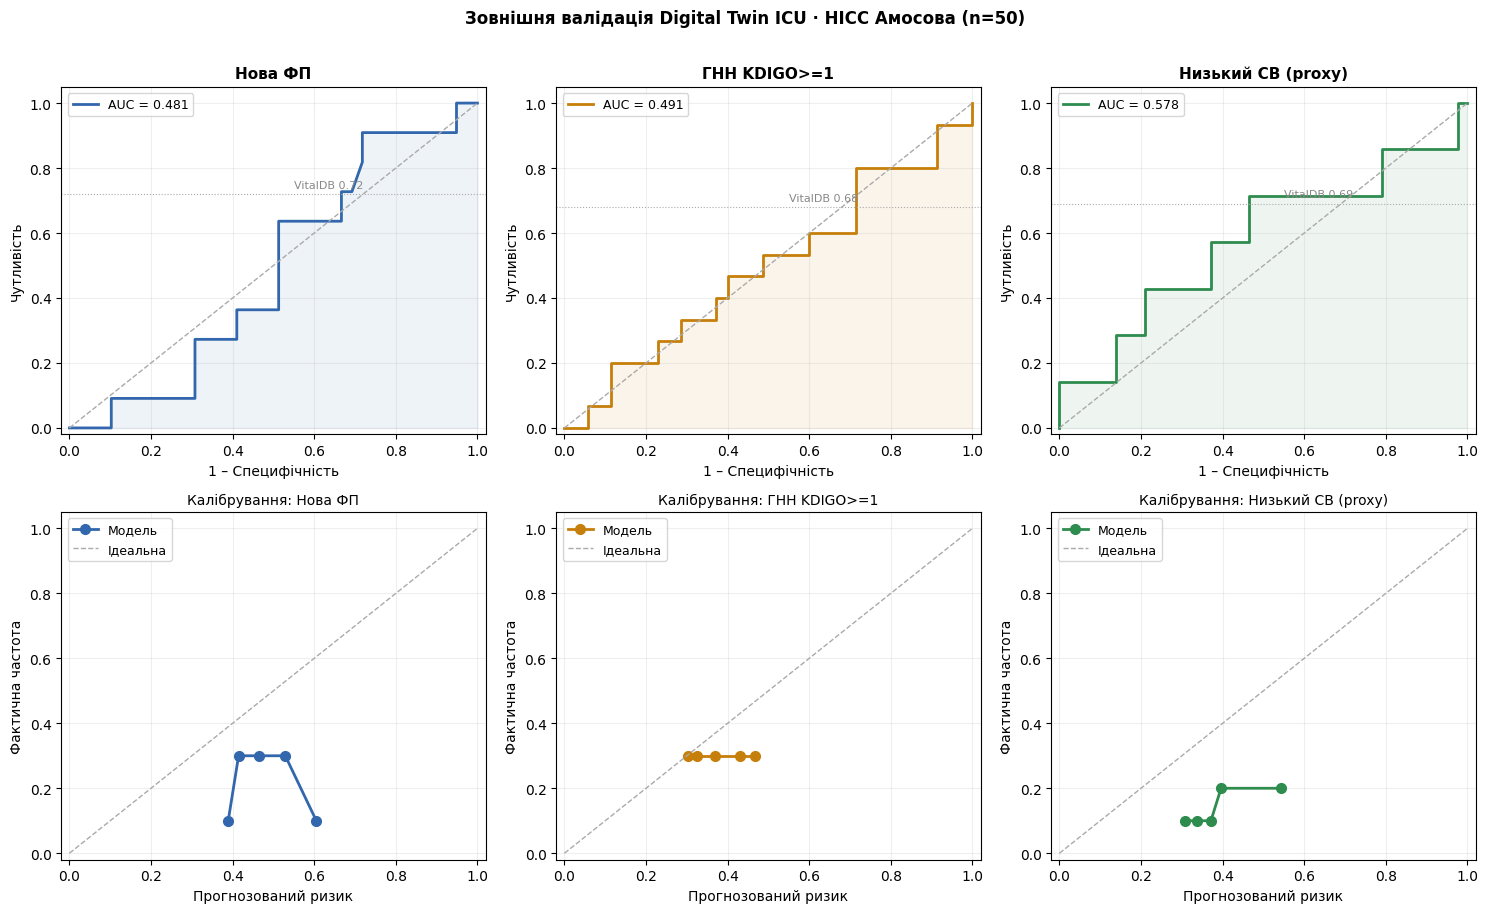

Збережено: validation_results.png

            Модель AUC (ваш датасет)  AUC (навчання)  AUC (VitalDB) Brier score
           Нова ФП             0.481           0.935           0.72       0.250
      ГНН KDIGO>=1             0.491           0.925           0.68       0.224
Низький СВ (proxy)             0.578           0.920           0.69       0.184
           Делірій                 –           0.910           0.71           –
  Дих. ускладнення                 –           0.925           0.73           –
Збережено: validation_summary.csv


In [ ]:
import warnings, joblib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')

CSV_PATH   = "/content/Контрольна група аспірантура.csv"
MODEL_DIR  = "/content/digital-twin-icu/models/cardiac"

# ── 1. Завантаження CSV ──────────────────────────────────────────
df_raw = pd.read_csv(CSV_PATH, sep=';', encoding='utf-8-sig', header=0)
df = df_raw[
    df_raw['ПІБ'].notna() &
    (df_raw['ПІБ'].str.strip() != '') &
    (df_raw['ПІБ'].str.startswith('ПІБ').fillna(False) == False)
].copy().reset_index(drop=True)
print(f"Пацієнтів: {len(df)}")

# ── 2. Парсинг ───────────────────────────────────────────────────
def num(v):
    try:
        return float(str(v).strip().replace(',','.').replace(' ','').replace('\xa0',''))
    except:
        return np.nan

def parse_age(v):
    m = re.findall(r'\d+', str(v))
    return int(m[0]) if m else np.nan

def parse_ckd(v):
    s = str(v).lower()
    for n, k in [(5,'g5'),(4,'g4'),(3,'g3'),(2,'g2'),(1,'g1')]:
        if k in s:
            return n
    return 0

df['age']      = df['Вік'].apply(parse_age)
df['hb_pre']   = df['Hb доопераційний, г/л'].apply(num)
df['cr_pre']   = df['Креатинін доопераційний, мкмоль/л'].apply(num)
df['cr_post']  = df['Креатинін післяопераційний'].apply(num)
df['ef']       = df['ФВ доопераційна, %'].apply(num)
df['ckd_pre']  = df['Ступінь ХХН по KDiGo доопераційний'].apply(parse_ckd)
df['ckd_post'] = df['Ступінь ХХН по KDiGo післяопераційний'].apply(parse_ckd)

df['diabetes'] = df['ЦД'].apply(
    lambda x: 0 if str(x).strip() in ['-','0','nan',''] else 1)

df['emergency'] = df['Взято ургентно/планово'].str.lower().str.contains(
    'ургент|екстрен', na=False).astype(int)

df['cpb_raw'] = df['ШК, 1 - був, 0 - не було'].apply(
    lambda x: 1 if str(x).strip() in ['1','Т','Так','так'] else 0)

df['ihd'] = df['Діагноз'].str.lower().str.contains(
    'іхс|ішемічна|атеросклероз|стенокард|інфаркт', na=False).astype(int)

op_col = 'Операція (назва, з ШК чи без)' if 'Операція (назва, з ШК чи без)' in df.columns else 'Операція '
df['surgery_cabg']  = df[op_col].str.lower().str.contains('акш|мкш', na=False).astype(int)
df['surgery_valve'] = df[op_col].str.lower().str.contains(
    'пак|пмк|плмк|плтк|атк|мнд|анд', na=False).astype(int)

# ── 3. Кінцеві точки ────────────────────────────────────────────
def postop_af(row):
    pre = str(row.get('Дані ЕКГ при поступленні', '')).lower()
    if any(k in pre for k in ['фп постійна', 'фібриляція передсердь']):
        return 0
    for col in ['Дані ЕКГ після операції', 'ШВРС', 'Порушення ритму в анамнезі']:
        v = str(row.get(col, '')).lower()
        if 'фп' in v or 'фібриляція' in v:
            return 1
    return 0

def aki(row):
    cp, cpo = row['cr_pre'], row['cr_post']
    if pd.notna(cp) and pd.notna(cpo) and cp > 0:
        if cpo / cp >= 1.5 or cpo - cp >= 26.5:
            return 1
    if row['ckd_pre'] < row['ckd_post'] >= 3:
        return 1
    return 0

df['y_af']  = df.apply(postop_af, axis=1)
df['y_aki'] = df.apply(aki, axis=1)
df['y_ino'] = df['Підтримка симпатоміметиками після операції/терапії'].apply(
    lambda x: 1 if pd.notna(x) and str(x).strip() not in ['-','0','ні','nan','Ні',''] else 0)

print(f"ФП:    {df['y_af'].sum()}  ({df['y_af'].mean()*100:.1f}%)")
print(f"ГНН:   {df['y_aki'].sum()} ({df['y_aki'].mean()*100:.1f}%)")
print(f"Інотр: {df['y_ino'].sum()} ({df['y_ino'].mean()*100:.1f}%)")

# ── 4. Матриця ознак ─────────────────────────────────────────────
X = pd.DataFrame({
    'age':               df['age'],
    'sex':               1,
    'weight':            80,
    'height':            172,
    'bmi':               27.0,
    'creatinine':        df['cr_pre'] / 88.4,
    'hemoglobin':        df['hb_pre'] / 10,
    'glucose':           5.5,
    'diabetes':          df['diabetes'],
    'hypertension':      df['ihd'],
    'ckd_stage':         df['ckd_pre'],
    'copd':              0,
    'smoking':           0,
    'asa_class':         3,
    'ejection_fraction': df['ef'],
    'ihd':               df['ihd'],
    'cpb_duration':      df['cpb_raw'] * 90,
    'surgery_cabg':      df['surgery_cabg'],
    'surgery_valve':     df['surgery_valve'],
    'surgery_duration':  240,
})
X = X.fillna(X.median())
print(f"\nМатриця ознак: {X.shape}")

# ── 5. Прогнозування ─────────────────────────────────────────────
MODELS = {
    'af':          (f'{MODEL_DIR}/model_cardiac_af_v2.pkl',          df['y_af'],  'Нова ФП'),
    'aki':         (f'{MODEL_DIR}/model_cardiac_aki_v2.pkl',         df['y_aki'], 'ГНН KDIGO>=1'),
    'lco':         (f'{MODEL_DIR}/model_cardiac_lco_v2.pkl',         df['y_ino'], 'Низький СВ (proxy)'),
    'delirium':    (f'{MODEL_DIR}/model_cardiac_delirium_v2.pkl',    None,        'Делірій'),
    'respiratory': (f'{MODEL_DIR}/model_cardiac_respiratory_v2.pkl', None,        'Дих. ускладнення'),
}

PUB_TRAIN = {'af':0.935,'aki':0.925,'lco':0.920,'delirium':0.910,'respiratory':0.925}
PUB_VAL   = {'af':0.72, 'aki':0.68, 'lco':0.69, 'delirium':0.71, 'respiratory':0.73}

results = {}
for key, (path, y_true, label) in MODELS.items():
    m = joblib.load(path)
    y_prob = m.predict_proba(X)[:, 1]
    row = {'label':label, 'y_prob':y_prob, 'y_true':None, 'auc':np.nan, 'brier':np.nan}
    if y_true is not None and y_true.sum() >= 5:
        row['y_true'] = y_true.values
        row['auc']    = roc_auc_score(y_true, y_prob)
        row['brier']  = brier_score_loss(y_true, y_prob)
    results[key] = row
    auc_str = f"{row['auc']:.3f}" if not np.isnan(row['auc']) else "–"
    pt = PUB_TRAIN.get(key, '–')
    pv = PUB_VAL.get(key, '–')
    print(f"{label:30s}  AUC={auc_str}  (навч={pt}, VitalDB={pv})")

# ── 6. Графіки ───────────────────────────────────────────────────
valid = {k:v for k,v in results.items()
         if v['y_true'] is not None and not np.isnan(v['auc'])}
n = len(valid)

fig, axes = plt.subplots(2, n, figsize=(5*n, 9))
if n == 1:
    axes = axes.reshape(2, 1)
colors = ['#3266ad','#c67f0a','#2d8c4e']

for i, (key, res) in enumerate(valid.items()):
    yt  = res['y_true']
    yp  = res['y_prob']
    col = colors[i % len(colors)]

    ax = axes[0, i]
    fpr, tpr, _ = roc_curve(yt, yp)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"AUC = {res['auc']:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.08, color=col)
    ax.plot([0,1],[0,1],'--', color='#aaa', lw=1)
    pub = PUB_VAL.get(key)
    if pub:
        ax.axhline(pub, color='#aaa', lw=0.8, linestyle=':')
        ax.text(0.55, pub+0.02, f"VitalDB {pub}", fontsize=8, color='#888')
    ax.set_title(res['label'], fontweight='bold', fontsize=11)
    ax.set_xlabel('1 – Специфічність')
    ax.set_ylabel('Чутливість')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.set_xlim([-0.02,1.02])
    ax.set_ylim([-0.02,1.05])

    ax2 = axes[1, i]
    try:
        nb = min(5, int(yt.sum()))
        fp, mp = calibration_curve(yt, yp, n_bins=nb, strategy='quantile')
        ax2.plot(mp, fp, 'o-', color=col, lw=2, ms=7, label='Модель')
    except Exception as e:
        ax2.text(0.3, 0.5, str(e), fontsize=8)
    ax2.plot([0,1],[0,1],'--', color='#aaa', lw=1, label='Ідеальна')
    ax2.set_title(f"Калібрування: {res['label']}", fontsize=10)
    ax2.set_xlabel('Прогнозований ризик')
    ax2.set_ylabel('Фактична частота')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.2)
    ax2.set_xlim([-0.02,1.02])
    ax2.set_ylim([-0.02,1.05])

plt.suptitle('Зовнішня валідація Digital Twin ICU · НІСС Амосова (n=50)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/validation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Збережено: validation_results.png")

# ── 7. Таблиця ───────────────────────────────────────────────────
rows = []
for key, res in results.items():
    rows.append({
        'Модель':            res['label'],
        'AUC (ваш датасет)': f"{res['auc']:.3f}" if not np.isnan(res['auc']) else "–",
        'AUC (навчання)':    PUB_TRAIN.get(key, '–'),
        'AUC (VitalDB)':     PUB_VAL.get(key, '–'),
        'Brier score':       f"{res['brier']:.3f}" if not np.isnan(res['brier']) else "–",
    })
summary = pd.DataFrame(rows)
print("\n" + summary.to_string(index=False))
summary.to_csv('/content/validation_summary.csv', index=False, encoding='utf-8-sig')
print("Збережено: validation_summary.csv")

In [ ]:
for key, res in results.items():
    if res['y_true'] is None:
        continue
    yt = res['y_true']
    yp = res['y_prob']
    has = yp[yt == 1]
    no  = yp[yt == 0]
    print(f"\n{res['label']}")
    print(f"  Середній ризик при наявності ускладнення:  {has.mean():.3f}")
    print(f"  Середній ризик при відсутності ускладнення: {no.mean():.3f}")


Нова ФП
  Середній ризик при наявності ускладнення:  0.471
  Середній ризик при відсутності ускладнення: 0.483

ГНН KDIGO>=1
  Середній ризик при наявності ускладнення:  0.374
  Середній ризик при відсутності ускладнення: 0.381

Низький СВ (proxy)
  Середній ризик при наявності ускладнення:  0.416
  Середній ризик при відсутності ускладнення: 0.387
